## 📌 **Informe de Laboratorio**
  ###  Sensor giroscopio MPU6050 Y ServoMotor

        Laboratorio Avanzado I


### 👥 **Integrantes del grupo:**

- Cristian Vergara
- Francesco Luligo
- Juan Jose Palacio
- Sofia Moscoso Ortiz

---

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## **Resumen**
Se desarrollo una actividad práctica de control y monitoreo, donde la placa Arduino se utilizó como microcontrolador principal. El objetivo central fue implementar un sistema que detectara la inclinación utilizando un giroscopio MPU6050 y ajustara automáticamente un servomotor para mantenerlo siempre en posición horizontal. El monitoreo se realizo mediante la creación de una página web, lo que permitió visualizar el movimiento del servomotor en tiempo real.

## **Introducción**
Un Arduino es un microcontrolador de hardware libre ampliamente empleado en proyectos electrónicos y de automatización por su facilidad de uso, su entorno de programación intuitivo y su versatilidad para interactuar con sensores y actuadores. El giroscopio MPU6050, es un instrumento de medicion, el cual contiene un módulo que integra un acelerómetro y un giroscopio capaces de detectar aceleración lineal y velocidad angular en tres ejes, permite entonces obtener información precisa sobre la inclinación y el movimiento de un sistema.

Los datos obtenidos por el MPU6050 fueron procesados por el Arduino para controlar un servomotor, este tipo de motor esta diseñado para ofrecer un control preciso sobre la posición angular o lineal, la velocidad y la aceleración, funciona mediante señales PWM.  A diferencia de un motor de corriente continua estándar que gira libremente, un servomotor puede moverse hasta un ángulo determinado y mantener esa posición de manera exacta. Este servomotor entonces, ajusta continuamente su posición con el fin de contrarrestar cualquier cambio de orientación detectado por el sensor MPU6050, manteniéndose así en posición horizontal.

Además del montaje físico, se desarrolló una página web que muestra en tiempo real el movimiento del servomotor. Esta interfaz permite visualizar de manera clara el comportamiento del sistema, facilitando el análisis de su respuesta ante variaciones en la inclinación. En conjunto, el proyecto integra hardware, control y visualización, ofreciendo una demostración práctica del uso de sensores y actuadores en aplicaciones de estabilización.

## **Procedimiento:**  
1. Se creo un codigo de arduino que nos imprimiera en tiempo real  en la pantalla las medidas tomadas por el giroscopio con el fin de verificar su funcionamiento. Este codigo ademas, es la base de la lectura de las medidas que se usaron posteriormente para controlar el servomotor.

2. Se implemento el codigo que controla el servomotor con el movimiento del sensor giroscopio MPU6050. De esta manera, cada cambio en la inclinación detectado por el MPU6050 se reflejó inmediatamente en el movimiento del servomotor, permitiendo que este se ajustara automáticamente para mantener una posición estable.

3. Desarrollo de la pagina web. En su interfaz se incorporaron elementos gráficos, como un rectángulo animado que rota simulando la inclinación detectada por el sensor, así como indicadores numéricos del ángulo calculado

*todos los codigos son en arduino**

##Verificacion Giroscopio
Se leyeron los datos del sensor MPU6050 usando la librería de Adafruit y se Imprime los valores por el monitor serie.


In [ ]:
#include <Adafruit_MPU6050.h>
#include <Adafruit_Sensor.h>
#include <Wire.h>

Adafruit_MPU6050 mpu;

void setup(void) {
  Serial.begin(115200);
  while (!Serial) {
    delay(10); // will pause Zero, Leonardo, etc until serial console opens
  }

  Serial.println("Adafruit MPU6050 test!");

  // Try to initialize!
  if (!mpu.begin()) {
    Serial.println("Failed to find MPU6050 chip");
    while (1) {
      delay(10);
    }
  }
  Serial.println("MPU6050 Found!");
void loop() {
  /* Get new sensor events with the readings */
  sensors_event_t a, g, temp;
  mpu.getEvent(&a, &g, &temp);

  /* Print out the values */
  Serial.print("Acceleration X: ");
  Serial.print(a.acceleration.x);
  Serial.print(", Y: ");
  Serial.print(a.acceleration.y);
  Serial.print(", Z: ");
  Serial.print(a.acceleration.z);
  Serial.println(" m/s^2");

  Serial.print("Rotation X: ");
  Serial.print(g.gyro.x);
  Serial.print(", Y: ");
  Serial.print(g.gyro.y);
  Serial.print(", Z: ");
  Serial.print(g.gyro.z);
  Serial.println(" rad/s");

  Serial.print("Temperature: ");
  Serial.print(temp.temperature);
  Serial.println(" degC");

  Serial.println("");
  delay(500);
}

## Control del servo motor con sensor MPU
Este programa conecta un MPU6050 y un servomotor en el arduino.
Lee los valores del acelerómetro, calcula el ángulo Roll usando la aceleración, convierte ese ángulo a un valor entre 0° y 180°  de modo que el servomotor mantenga horizontal y finalmente muestra el ángulo por Serial.

In [ ]:
#include &lt;Wire.h&gt;
#include &lt;MPU6050.h&gt;
#include &lt;ESP32Servo.h&gt;
MPU6050 mpu;
Unsigned long TiempoAnterior = 0;
Constant long intervalo = 20 // 20 milisegundos
// Servo
Servo myservo;

int servoPin = 18; // Cambia a tu pin
int angulo;
// Variables de MPU
int16_t ax, ay, az;
int16_t gx, gy, gz;
// Conversión de aceleración a ángulo
float getAngle(int16_t ax, int16_t ay, int16_t az) {
float angle = atan2(ay, az) * 180 / PI;
return angle;
}
void setup() {
Serial.begin(115200);
Wire.begin();
// Inicializar MPU6050
Serial.println(&quot;Inicializando MPU6050...&quot;);
mpu.initialize();
if (!mpu.testConnection()) {
Serial.println(&quot;Error: MPU6050 no encontrado!&quot;);
while (1);
}
// Inicializar servo (ESP32Servo)
ESP32PWM::allocateTimer(0);
ESP32PWM::allocateTimer(1);
ESP32PWM::allocateTimer(2);
ESP32PWM::allocateTimer(3);
myservo.setPeriodHertz(50); // 50 Hz para servo
myservo.attach(servoPin, 500, 2400); // min y max
microsegundos
Serial.println(&quot;Todo listo.&quot;);
}
void loop() {
// Leer acelerómetro
mpu.getAcceleration(&amp;ax, &amp;ay, &amp;az);
// Calcular ángulo

float anguloMPU = getAngle(ax, ay, az);
// Limitar ángulo a 0–180
angulo = map((int)anguloMPU, -90, 90, 0, 180);
angulo = constrain(angulo, 0, 180);
// Mover servo
myservo.write(angulo);
// Mostrar datos
Serial.print(&quot;Ángulo: &quot;);
Serial.println(angulo);
delay(20);
}

#Visualizar el valor del sensor MPU6050 en una página HTML
Este programa convierte el arduino en un sistema de monitoreo en tiempo real que lee ángulos de inclinación desde el MPU6050, con los cuales se controla el movimiento del servomotor, los procesa con un filtro complementario para mayor estabilidad y los visualiza en tiempo real mediante una interfaz web accesible desde cualquier dispositivo conectado a la misma red WiFi.

In [ ]:
#include <WiFi.h>
#include <WebServer.h>
#include <Wire.h>
#include <Adafruit_MPU6050.h>
#include <Adafruit_Sensor.h>

// ==========================================
// 1. CONFIGURACIÓN WIFI
// ==========================================
const char* SSID = "Berserker";
const char* PASSWORD = "soylindoyrico";

// ==========================================
// VARIABLES GLOBALES
// ==========================================
WebServer server(80);
WiFiClient clients[10];
int client_count = 0;
Adafruit_MPU6050 mpu;

float roll = 0, pitch = 0;
float alpha = 0.98; // Factor del filtro complementario
unsigned long lastTime = 0;

// ==========================================
// CÓDIGO HTML DE LA PÁGINA WEB
// ==========================================
const char INDEX_HTML[] PROGMEM = R"rawliteral(
<!doctype html>
<html>
<head>
  <meta charset='utf-8'>
  <title>ESP32 MPU6050 Live</title>
  <style>
    body{font-family:Arial;text-align:center;margin:0;padding:20px;}
    h2{color:#333;}
    canvas{background:#f0f0f0;margin-top:20px;border:2px solid #444;border-radius:8px;box-shadow:0 4px 6px rgba(0,0,0,0.1);}
    .info{margin-top:15px;font-size:1.2em;color:#555;}
    span{font-weight:bold;color:#007BFF;}
  </style>
</head>
<body>
  <h2>Visualización MPU6050 - ESP32</h2>
  <div class='info'>
    Inclinación X (Roll): <span id='roll'>0</span>&deg; &nbsp;|&nbsp;
    Inclinación Y (Pitch): <span id='pitch'>0</span>&deg;
  </div>
  <canvas id='c' width='400' height='300'></canvas>

  <script>
    const evtSource = new EventSource('/stream');
    let roll = 0, pitch = 0;

    evtSource.onmessage = function(e) {
      const d = JSON.parse(e.data);
      roll = d.roll;
      pitch = d.pitch;
      document.getElementById('roll').innerText = roll.toFixed(1);
      document.getElementById('pitch').innerText = pitch.toFixed(1);
    };

    const c = document.getElementById('c');
    const ctx = c.getContext('2d');

    function draw() {
      ctx.clearRect(0, 0, c.width, c.height);
      ctx.save();
      ctx.translate(c.width / 2, c.height / 2);

      // Rotación del objeto
      ctx.rotate(roll * Math.PI / 180);
      // (Puedes descomentar la siguiente línea si quieres rotar en dos ejes,
      // aunque en 2D es mejor ver solo uno a la vez o simular 3D)
      // ctx.rotate(pitch * Math.PI / 180);

      // Dibujar el "cubo" (rectángulo)
      ctx.fillStyle = '#007BFF';
      ctx.fillRect(-80, -40, 160, 80); // Cuerpo principal

      ctx.fillStyle = '#0056b3'; // Un borde para ver el movimiento mejor
      ctx.fillRect(-80, -40, 20, 80);

      ctx.restore();
      requestAnimationFrame(draw);
    }
    draw();
  </script>
</body>
</html>
)rawliteral";

// ==========================================
// FUNCIONES DEL SERVIDOR
// ==========================================
void sendSSEHeaders(WiFiClient &client) {
  client.print("HTTP/1.1 200 OK\r\n");
  client.print("Content-Type: text/event-stream\r\n");
  client.print("Cache-Control: no-cache\r\n");
  client.print("Connection: keep-alive\r\n\r\n");
}

void handleRoot() {
  server.send(200, "text/html", INDEX_HTML);
}

void handleStream() {
  WiFiClient client = server.client();
  sendSSEHeaders(client);
  if (client_count < 10) {
    clients[client_count++] = client;
  }
}
// ===========================
// LECTURA MPU6050 Y ENVÍO SSE
// ===========================

void sendIMUData() {
  sensors_event_t a, g, temp;
  mpu.getEvent(&a, &g, &temp);

  float ax = a.acceleration.x;
  float ay = a.acceleration.y;
  float az = a.acceleration.z;

  // Convertir giroscopio a grados/segundo (opcional si usas filtro complejo)
  float gx = g.gyro.x * 57.2958;
  float gy = g.gyro.y * 57.2958;

  // Calcular ángulos con acelerómetro
  float acc_roll = atan2(ay, az) * 180 / PI;
  float acc_pitch = atan2(-ax, sqrt(ay * ay + az * az)) * 180 / PI;

  // Filtro para suavizar movimiento
  unsigned long now = millis();
  float dt = (now - lastTime) / 1000.0;
  lastTime = now;

  // Fórmula del Filtro Complementario
  roll = alpha * (roll + gx * dt) + (1 - alpha) * acc_roll;
  pitch = alpha * (pitch + gy * dt) + (1 - alpha) * acc_pitch;

  //ServoMotor
  servoAngulo = map((int)roll, -90, 90, 0, 180);
  servoAngulo = constrain(servoAngulo, 0, 180);
  myservo.write(servoAngulo);


  // Crear JSON para enviar a la web
  String payload = "{\"roll\":";
  payload += String(roll, 2);
  payload += ",\"pitch\":";
  payload += String(pitch, 2);
  payload += "}";

  // Enviar a todos los navegadores conectados
  for (int i = 0; i < client_count; i++) {
    if (clients[i].connected()) {
      clients[i].print("data: " + payload + "\n\n");
    } else {
      clients[i].stop(); // Cerrar conexiones viejas
    }
  }
}

// ==========================================
// SETUP
// ==========================================
void setup() {
  Serial.begin(115200);

  //  Configurar Servo
  ESP32PWM::allocateTimer(0);
  ESP32PWM::allocateTimer(1);
  ESP32PWM::allocateTimer(2);
  ESP32PWM::allocateTimer(3);
  myservo.setPeriodHertz(50);
  myservo.attach(servoPin, 500, 2400);
  myservo.write(90); // Posición inicial centro


  // 1. Iniciar WiFi
  Serial.print("Conectando a ");
  Serial.println(SSID);
  WiFi.begin(SSID, PASSWORD);
  while (WiFi.status() != WL_CONNECTED) {
    delay(500);
    Serial.print(".");
  }
  Serial.println("");
  Serial.println("WiFi conectado.");
  Serial.print("DIRECCIÓN IP PARA ENTRAR: http://");
  Serial.println(WiFi.localIP()); // <--- ¡MIRA ESTO EN EL MONITOR SERIE!

  // 2. Iniciar MPU6050
  if (!mpu.begin()) {
    Serial.println("¡No se encuentra el chip MPU6050! Revisa cables.");
    while (1) { delay(10); }
  }
  Serial.println("MPU6050 encontrado.");

  mpu.setAccelerometerRange(MPU6050_RANGE_4_G);
  mpu.setGyroRange(MPU6050_RANGE_500_DEG);
  mpu.setFilterBandwidth(MPU6050_BAND_21_HZ);

  // 3. Iniciar Servidor Web
  server.on("/", handleRoot);
  server.on("/stream", handleStream);
  server.begin();
  Serial.println("Servidor web iniciado.");

  lastTime = millis();
}

// ==========================================
// LOOP
// ==========================================
void loop() {
  server.handleClient();
  procesarDatos();
  sendIMUData();
  delay(20);
}

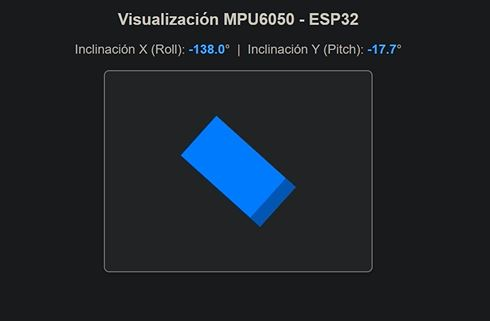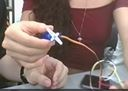

##Conclusion
En esta práctica se logró integrar con éxito el sensor MPU6050 con un servomotor, demostrando cómo las mediciones de inclinación pueden controlarlo, mientras que la implementación de un servidor web en el microcontrolador facilitó la visualización de los ángulos de roll y pitch de manera gráfica. Además, se comprobó la importancia de calibrar y mapear correctamente los valores del sensor al rango del servo. La actividad permitió consolidar conocimientos de programación en Arduino, electrónica y desarrollo de interfaces web interactivas, mostrando la aplicabilidad de estos sistemas en control y monitoreo automático.